In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout = 0.1):
        super(ScaledDotProductAttention, self).__init__()
        self.dropout = nn.Dropout()
    def forward(self, Q, K, V, masked = None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1))/math.sqrt(d_k)

        if masked is not None:
            scores = scores.masked_fill(masked == 0, -1e4)

        attn_weights = torch.softmax(scores, dim = -1)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, V)

        return context, attn_weights


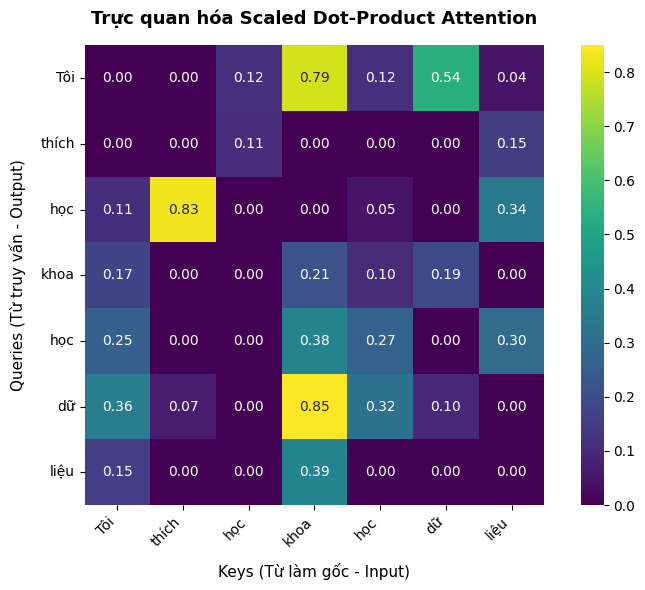

In [ ]:
attention_layer = ScaledDotProductAttention(dropout=0.0)
batch_size = 1
num_heads = 1
seq_len = 7
d_k = 8

torch.manual_seed(42)
Q = torch.randn(batch_size, num_heads, seq_len, d_k)
K = torch.randn(batch_size, num_heads, seq_len, d_k)
V = torch.randn(batch_size, num_heads, seq_len, d_k)

with torch.no_grad():
    context, attn_weights = attention_layer(Q, K, V)

attention_matrix = attn_weights[0, 0].detach().cpu().numpy()
words = ["Tôi", "thích", "học", "khoa", "học", "dữ", "liệu"]
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=words,
    yticklabels=words,
    square=True,
)

plt.title(
    "Trực quan hóa Scaled Dot-Product Attention",
    fontsize=13,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Keys (Từ làm gốc - Input)", fontsize=11, labelpad=10)
plt.ylabel("Queries (Từ truy vấn - Output)", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()